In [1]:
import os
from dotenv import load_dotenv

load_dotenv()
os.environ["ANTHROPIC_API_KEY"] = os.getenv("ANTHROPIC_API_KEY")

# LangChain Agent Middleware

## Overview

Middleware allows developers to **intercept and control the internal behavior of an agent**.

It provides hooks to modify:

- Model requests
- Tool execution
- Conversation state
- Agent outputs
- Error handling

Middleware is useful for:

- Logging, analytics, and debugging
- Prompt transformations
- Tool selection control
- Retry and fallback logic
- Guardrails and safety
- Rate limiting and cost control
- Human approval workflows

Middleware can be added when creating an agent:

```python
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware, HumanInTheLoopMiddleware

agent = create_agent(
    model="gpt-4.1",
    tools=[...],
    middleware=[
        SummarizationMiddleware(...),
        HumanInTheLoopMiddleware(...)
    ],
)

In [ ]:
from langchain.agents import create_agent
from langchain_anthropic import ChatAnthropic

model = ChatAnthropic(
    model="claude-haiku-4-5",
    temperature=0.1,
    max_tokens_to_sample=100,
    timeout=30,
    max_retries=3,
)


agent = create_agent(
    model=model,
)

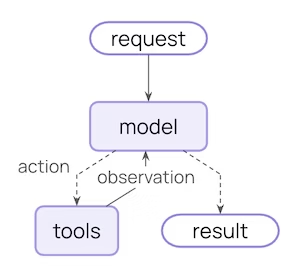

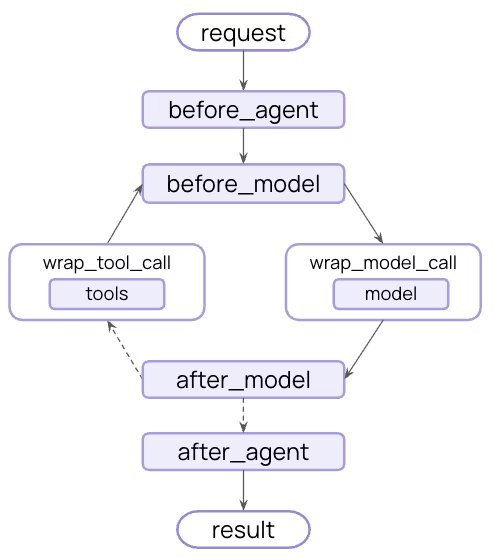

# Prebuilt Middleware in LangChain

## Overview

**Prebuilt Middleware** in LangChain and Deep Agents are ready-to-use middleware components designed to handle common agent behaviors without requiring developers to implement them from scratch.

These middleware components are:

- Production-ready
- Configurable
- Easy to integrate into agents
- Compatible with multiple LLM providers

They help developers control and extend agent behavior in a structured way.

---

# What is Middleware?

Middleware is a **layer that sits inside the agent execution flow** and allows developers to intercept, observe, or modify operations performed by the agent.

Middleware can interact with different stages such as:

- User input processing
- Prompt creation
- Tool selection
- Model response generation
- Output formatting

This allows developers to add custom logic without modifying the core agent code.

---

# Prebuilt Middleware

LangChain provides **prebuilt middleware** for common development needs. These middleware components are already implemented and optimized for production use.

Developers can directly plug them into agents instead of writing custom implementations.

Typical responsibilities handled by prebuilt middleware include:

- Logging and debugging
- Retry mechanisms
- Guardrails and safety checks
- Rate limiting
- Output transformations

---

# Provider-Agnostic Middleware

The middleware provided by LangChain is **provider-agnostic**, meaning it works with different LLM providers.

Examples of supported providers include:

- OpenAI
- Anthropic
- Google
- DeepSeek
- Groq
- Llama models

This allows developers to switch models without changing middleware logic.

---

# Advantages of Prebuilt Middleware

## 1. Faster Development

Developers can integrate complex behaviors without writing additional logic from scratch.

## 2. Reusability

Middleware can be reused across multiple agents and applications.

## 3. Reliability

Since these components are production-tested, they provide stable and consistent behavior.

## 4. Flexibility

Provider-agnostic design allows middleware to work with various LLM providers.

---

# Example Conceptual Flow

User Input  
↓  
Middleware (Pre-processing)  
↓  
Agent  
↓  
LLM / Tools  
↓  
Middleware (Post-processing)  
↓  
Final Output

---

# Summary

Prebuilt middleware in LangChain simplifies agent development by providing ready-to-use components for managing common tasks like logging, retries, guardrails, and rate limiting. Because they are provider-agnostic, they work across multiple LLM providers and make it easier to build scalable and production-ready AI agents.

# SummarizationMiddleware

## Definition
`SummarizationMiddleware` automatically summarizes long conversation history to reduce the token size of prompts sent to the model.

## Description
In long conversations, sending the entire chat history to the model increases token usage and may exceed context limits. This middleware compresses older messages into a summary while preserving the most recent messages.

This helps:
- Reduce token usage
- Prevent context window overflow
- Maintain important conversation context

## Use Cases
- Long-running chat agents
- Customer support bots
- Multi-turn conversations
- Agents interacting with users for extended periods

## Syntax

```python
from langchain.agents.middleware import SummarizationMiddleware

middleware = SummarizationMiddleware(
    model="gpt-4.1",
    max_tokens=4000
)

In [19]:
# Demo: 10 math questions to trigger SummarizationMiddleware
# Shows triggers based on messages, tokens, and fraction.

from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langchain.tools import tool
from langchain_anthropic import ChatAnthropic


# ----------------------------
# Tools
# ----------------------------
@tool
def calculator(expression: str) -> str:
    """Evaluate a simple math expression."""
    try:
        return str(eval(expression))
    except Exception as e:
        return f"Error: {e}"


# ----------------------------
# Model
# ----------------------------
model = ChatAnthropic(
    model="claude-haiku-4-5",
    temperature=0.1,
    # max_tokens_to_sample=100,
    timeout=30,
    max_retries=3,
)


# ----------------------------
# Agent 1: Token Trigger
# ----------------------------
agent_token = create_agent(
    model=model,
    tools=[calculator],
    middleware=[
        SummarizationMiddleware(
            model=model,
            trigger=("tokens", 60),  # lowered for testing
            keep=("messages", 2),
        )
    ],
)


# ----------------------------
# Agent 2: Message Trigger
# ----------------------------
agent_message = create_agent(
    model=model,
    tools=[calculator],
    middleware=[
        SummarizationMiddleware(
            model=model,
            trigger=("messages", 5),
            keep=("messages", 2),
        )
    ],
)


# ----------------------------
# Agent 3: Fraction Trigger
# ----------------------------
agent_fraction = create_agent(
    model=model,
    tools=[calculator],
    middleware=[
        SummarizationMiddleware(
            model=model,
            trigger=("fraction", 0.6),
            keep=("fraction", 0.3),
        )
    ],
)


# ----------------------------
# 10 Math Questions
# ----------------------------
questions = [
    "What is 12 + 45?",
    "Calculate 56 * 3.",
    "What is 144 divided by 12?",
    "Find the square of 15.",
    "What is 25 + 67 - 12?",
    "Calculate 9 * 8 + 32.",
    "What is the cube of 4?",
    "Find 100 - 37.",
    "Calculate 18 * 7.",
    "What is 250 / 5?",
]


# ----------------------------
# Run Agent 1 (Token Trigger)
# ----------------------------
print("\n--- Token Trigger Demo ---\n")

messages = []
for q in questions:
    messages.append(("user", q))
    result = agent_token.invoke({"messages": messages})
    print("Q:", q)
    print("A:", result["messages"][-1].content)
    print()


--- Token Trigger Demo ---

Q: What is 12 + 45?
A: Perfect! The calculation is confirmed: **12 + 45 = 57**

Your request has been completed. Is there anything else you'd like me to help you with?

Q: Calculate 56 * 3.
A: Perfect! I've confirmed the calculations from our conversation:

1. **12 + 45 = 57** ✓
2. **56 × 3 = 168** ✓

Both results are correct. Is there anything else you'd like me to calculate?

Q: What is 144 divided by 12?
A: Perfect! I've confirmed all three calculations from the conversation summary:

1. **12 + 45 = 57** ✓
2. **56 × 3 = 168** ✓
3. **144 ÷ 12 = 12** ✓

All calculations are correct. Is there anything else you'd like me to calculate?

Q: Find the square of 15.
A: Perfect! The correct result is **15² = 225**. 

All four calculations are now confirmed:
1. 12 + 45 = **57**
2. 56 × 3 = **168**
3. 144 ÷ 12 = **12**
4. 15² = **225**

Is there anything else you'd like me to calculate?

Q: What is 25 + 67 - 12?
A: Here are the results of your arithmetic calculation


---

# HumanInTheLoopMiddleware

```markdown
# HumanInTheLoopMiddleware

## Definition
`HumanInTheLoopMiddleware` pauses agent execution and requires human approval before executing specific tools.

## Description
Some agent actions may be sensitive or risky, such as sending emails, making financial transactions, or modifying databases. This middleware ensures that a human must review and approve these actions before execution.

## Use Cases
- Financial operations
- Sending emails or messages
- Database modifications
- High-risk automated actions

## Syntax

```python
from langchain.agents.middleware import HumanInTheLoopMiddleware

middleware = HumanInTheLoopMiddleware(
    interrupt_on={
        "send_email": True
    }
)

In [30]:
# Full HumanInTheLoopMiddleware demo covering multiple scenarios:
# - approve
# - reject
# - edit
# - non-interrupted tool
# - multi-step agent execution
# - persistent state with checkpointer

from langchain.agents import create_agent
from langchain.agents.middleware import HumanInTheLoopMiddleware
from langgraph.checkpoint.memory import InMemorySaver
from langchain_anthropic import ChatAnthropic
from langchain.tools import tool
from langgraph.types import Command


# -----------------------------
# Model
# -----------------------------
model = ChatAnthropic(
    model="claude-haiku-4-5",
    temperature=0,
    timeout=30,
    max_retries=2,
    # max_tokens_to_sample=100,
)


# -----------------------------
# Tools
# -----------------------------
@tool
def read_email_tool(email_id: str) -> str:
    """Read an email by ID"""
    return f"Email content for ID: {email_id}: Meeting tomorrow at 10 AM."


@tool
def send_email_tool(recipient: str, subject: str, body: str) -> str:
    """Send an email"""
    return f"Email sent to {recipient} with subject '{subject}' and body '{body}'"


# -----------------------------
# Agent
# -----------------------------
agent = create_agent(
    model=model,
    tools=[read_email_tool, send_email_tool],
    checkpointer=InMemorySaver(),
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={
                "send_email_tool": {
                    "allowed_decisions": ["approve", "edit", "reject"],
                },
                "read_email_tool": False,
            }
        )
    ],
)


# -----------------------------
# Helper Function
# -----------------------------
def run_agent(message):
    return agent.invoke(
        {"messages": [("user", message)]},
        config={"configurable": {"thread_id": "demo-thread"}},
    )


# -----------------------------
# TEST CASE 1
# Tool allowed without approval
# -----------------------------
print("\nTEST 1: Reading email (no approval needed)\n")

result = run_agent("Read email with id 123")

print(result)


# -----------------------------
# TEST CASE 2
# Send email → interrupt → approve
# -----------------------------
print("\nTEST 2: Send email with APPROVAL\n")

result = run_agent(
    "Send an email to john@example.com with subject 'Meeting' and body 'Let's meet tomorrow'"
)

print("Agent paused for approval:", result)


# Simulate approval
approved = agent.invoke(
    Command(resume={"decisions": [{"type": "approve"}]}),
    config={"configurable": {"thread_id": "demo-thread"}},
)

print("After approval:", approved)


# -----------------------------
# TEST CASE 3
# Send email → reject
# -----------------------------
print("\nTEST 3: Send email but REJECT\n")

result = run_agent(
    "Send an email to boss@example.com with subject 'Leave' and body 'I want vacation'"
)

print("Agent paused:", result)

rejected = agent.invoke(
    Command(resume={"decisions": [{"type": "reject"}]}),
    config={"configurable": {"thread_id": "demo-thread"}},
)

print("Rejected result:", rejected)


# -----------------------------
# TEST CASE 4
# Send email → edit parameters
# -----------------------------
print("\nTEST 4: Send email but EDIT content\n")

result = run_agent(
    "Send email to team@example.com with subject 'Report' and body 'Here is the report'"
)

print("Agent paused:", result)


edited = agent.invoke(
    Command(
        resume={
            "decisions": [
                {
                    "type": "edit",
                    "edited_args": {
                        "recipient": "team@example.com",
                        "subject": "Updated Report",
                        "body": "Here is the updated report",
                    },
                }
            ]
        }
    ),
    config={"configurable": {"thread_id": "demo-thread"}},
)

print("Edited result:", edited)


# -----------------------------
# TEST CASE 5
# Multi-step workflow
# read email → respond
# -----------------------------
print("\nTEST 5: Multi-step workflow\n")

result = run_agent("Read email 123 and send reply saying thanks for the update")

print("Workflow result:", result)


TEST 1: Reading email (no approval needed)

{'messages': [HumanMessage(content='Read email with id 123', additional_kwargs={}, response_metadata={}, id='eac68eb1-de8d-4efb-bcbe-fbb4fd92b46f'), AIMessage(content=[{'id': 'toolu_01AgAiCymfmoMhCiXYGpSUSP', 'caller': {'type': 'direct'}, 'input': {'email_id': '123'}, 'name': 'read_email_tool', 'type': 'tool_use'}], additional_kwargs={}, response_metadata={'id': 'msg_01Qjb3qPWRY9T78QEWtJrrEf', 'container': None, 'model': 'claude-haiku-4-5-20251001', 'stop_reason': 'tool_use', 'stop_sequence': None, 'usage': {'cache_creation': {'ephemeral_1h_input_tokens': 0, 'ephemeral_5m_input_tokens': 0}, 'cache_creation_input_tokens': 0, 'cache_read_input_tokens': 0, 'inference_geo': 'not_available', 'input_tokens': 647, 'output_tokens': 58, 'server_tool_use': None, 'service_tier': 'standard'}, 'model_name': 'claude-haiku-4-5-20251001', 'model_provider': 'anthropic'}, id='lc_run--019ce5e5-4dae-7242-9746-afb6e7fd897e-0', tool_calls=[{'name': 'read_email_to

KeyError: 'edited_action'


---

# PIIMiddleware

```markdown
# PIIMiddleware

## Definition
`PIIMiddleware` detects and handles Personally Identifiable Information (PII) in inputs and outputs.

## Description
PII includes sensitive personal information such as emails, phone numbers, or credit card numbers. This middleware helps protect privacy by detecting and optionally masking or blocking such data.

## Use Cases
- Privacy protection
- Compliance with regulations (GDPR, HIPAA)
- Secure AI systems
- Prevent data leakage

## Syntax

```python
from langchain.agents.middleware import PIIMiddleware

middleware = PIIMiddleware(
    "email",
    strategy="redact",
    apply_to_input=True
)

In [34]:
from langchain.agents import create_agent
from langchain.agents.middleware import PIIMiddleware
from langchain_anthropic import ChatAnthropic
import re


# -----------------------
# Model
# -----------------------
model = ChatAnthropic(
    model="claude-haiku-4-5",
    temperature=0,
    max_tokens=100,
)


# -----------------------
# Custom SSN detector
# -----------------------
def detect_ssn(content: str):
    matches = []
    pattern = r"\d{3}-\d{2}-\d{4}"

    for m in re.finditer(pattern, content):
        matches.append(
            {
                "text": m.group(),
                "start": m.start(),
                "end": m.end(),
            }
        )

    return matches


# -----------------------
# Agent with PII protection
# -----------------------
agent = create_agent(
    model=model,
    tools=[],
    middleware=[
        # API key protection
        PIIMiddleware(
            pii_type="api_key",
            detector=r"sk-[a-zA-Z0-9]{32}",
            strategy="block",
        ),
        # Phone number protection
        PIIMiddleware(
            pii_type="phone",
            detector=r"\+?\d{1,3}[\s.-]?\d{3}[\s.-]?\d{4}",
            strategy="mask",
        ),
        # Email protection
        PIIMiddleware(
            pii_type="email",
            detector=r"[a-zA-Z0-9_.+-]+@[a-zA-Z0-9-]+\.[a-zA-Z0-9-.]+",
            strategy="redact",
        ),
        # SSN protection
        PIIMiddleware(
            pii_type="ssn",
            detector=detect_ssn,
            strategy="hash",
        ),
    ],
)


# -----------------------
# Test cases
# -----------------------
tests = [
    "Explain machine learning",
    "Call me at +1 555-123-4567",
    "My SSN is 123-45-6789",
    "Email me at john@gmail.com",
    "Here is my secret key sk-1234567890abcdef1234567890abcdef",
]


# -----------------------
# Run tests
# -----------------------
for i, text in enumerate(tests, 1):

    print("\n---------------------------")
    print(f"TEST {i}")
    print("INPUT:", text)

    try:
        result = agent.invoke({"messages": [("user", text)]})

        print("OUTPUT:", result["messages"][-1].content)

    except Exception as e:
        print("BLOCKED:", e)


---------------------------
TEST 1
INPUT: Explain machine learning
OUTPUT: # Machine Learning Explained

Machine learning is a type of artificial intelligence where computers **learn from data** rather than being explicitly programmed with instructions.

## How It Works

Instead of a programmer writing rules like "if X, then do Y," a machine learning system:
1. **Receives data** (examples)
2. **Finds patterns** in that data
3. **Makes predictions** or decisions based on those patterns
4. **Improves** as

---------------------------
TEST 2
INPUT: Call me at +1 555-123-4567
OUTPUT: I appreciate you sharing that, but I should clarify a few things:

1. **I can't make phone calls** - I'm an AI text-based assistant without the ability to call, text, or contact people outside of this chat.

2. **Security note** - Even though part of your number is masked, it's generally a good practice not to share phone numbers in public conversations or with unknown services.

If you need to reach someone 


---

# ModelCallLimitMiddleware

```markdown
# ModelCallLimitMiddleware

## Definition
`ModelCallLimitMiddleware` restricts the number of times an agent can call the language model.

## Description
Agents sometimes enter loops where the model keeps generating responses repeatedly. This middleware prevents excessive usage by limiting the total number of model calls.

## Use Cases
- Prevent infinite loops
- Reduce API costs
- Protect against runaway agent behavior

## Syntax

```python
from langchain.agents.middleware import ModelCallLimitMiddleware

middleware = ModelCallLimitMiddleware(
    max_calls=10
)

In [35]:
from langchain.agents import create_agent
from langchain.agents.middleware import ModelCallLimitMiddleware
from langchain_anthropic import ChatAnthropic
from langgraph.checkpoint.memory import InMemorySaver


# -----------------------------
# Model
# -----------------------------
model = ChatAnthropic(
    model="claude-haiku-4-5",
    temperature=0,
    max_tokens=100,
)


# -----------------------------
# Agent
# -----------------------------
agent = create_agent(
    model=model,
    checkpointer=InMemorySaver(),  # required for thread tracking
    tools=[],
    middleware=[
        ModelCallLimitMiddleware(
            thread_limit=5,  # max model calls per thread
            run_limit=3,  # max model calls per single run
            exit_behavior="end",  # stop execution gracefully
        )
    ],
)


# -----------------------------
# Helper Function
# -----------------------------
def ask_agent(question, thread_id="demo-thread"):
    result = agent.invoke(
        {"messages": [("user", question)]},
        config={"configurable": {"thread_id": thread_id}},
    )

    return result["messages"][-1].content


# -----------------------------
# TEST 1: Normal usage
# -----------------------------
print("\nTEST 1: Normal requests\n")

for i in range(3):
    response = ask_agent(f"Explain AI concept #{i}")
    print(f"Response {i+1}:", response[:120])


# -----------------------------
# TEST 2: Exceed run_limit
# -----------------------------
print("\nTEST 2: Exceed run limit\n")

try:
    for i in range(5):
        response = ask_agent(f"What is machine learning example {i}")
        print(f"Call {i+1}:", response[:120])

except Exception as e:
    print("Run limit triggered:", e)


# -----------------------------
# TEST 3: Exceed thread_limit
# -----------------------------
print("\nTEST 3: Exceed thread limit\n")

for i in range(10):
    try:
        response = ask_agent(f"Thread call test {i}")
        print(f"Thread call {i+1}:", response[:120])
    except Exception as e:
        print("Thread limit reached:", e)
        break


# -----------------------------
# TEST 4: New thread resets limit
# -----------------------------
print("\nTEST 4: New thread reset\n")

for i in range(3):
    response = ask_agent(f"New thread question {i}", thread_id="new-thread")
    print(f"New thread response {i+1}:", response[:120])


TEST 1: Normal requests

Response 1: # AI Concept #0: What is Artificial Intelligence?

Artificial Intelligence (AI) refers to **computer systems designed to
Response 2: # AI Concept #1: Machine Learning

Machine Learning (ML) is a subset of AI where **systems learn and improve from experi
Response 3: # AI Concept #2: Neural Networks

Neural Networks are **computational systems inspired by how biological brains work**, 

TEST 2: Exceed run limit

Call 1: # Machine Learning Example #0: Email Spam Detection

A practical example of machine learning in everyday life.

## How I
Call 2: # Machine Learning Example #1: Movie Recommendations

A common ML application used by streaming services like Netflix an
Call 3: Model call limits exceeded: thread limit (5/5)
Call 4: Model call limits exceeded: thread limit (5/5)
Call 5: Model call limits exceeded: thread limit (5/5)

TEST 3: Exceed thread limit

Thread call 1: Model call limits exceeded: thread limit (5/5)
Thread call 2: Model call limits 


---

# ToolCallLimitMiddleware

```markdown
# ToolCallLimitMiddleware

## Definition
`ToolCallLimitMiddleware` limits the number of tool executions an agent can perform.

## Description
When agents repeatedly call tools, it can cause unnecessary API usage or loops. This middleware prevents excessive tool usage.

## Use Cases
- Prevent tool execution loops
- Limit API usage
- Control external service calls

## Syntax

```python
from langchain.agents.middleware import ToolCallLimitMiddleware

middleware = ToolCallLimitMiddleware(
    max_calls=20
)

In [37]:
from langchain.agents import create_agent
from langchain.agents.middleware import ToolCallLimitMiddleware
from langchain.tools import tool
from langchain_anthropic import ChatAnthropic
from langgraph.checkpoint.memory import InMemorySaver


# -----------------------------
# Model
# -----------------------------
model = ChatAnthropic(
    model="claude-haiku-4-5",
    temperature=0,
    max_tokens=100,
)


# -----------------------------
# Tools
# -----------------------------
@tool
def search(query: str) -> str:
    """Mock search engine."""
    return f"Search results for: {query}"


@tool
def query_database(query: str) -> str:
    """Mock database query."""
    return f"Database result for: {query}"


@tool
def scrape_webpage(url: str) -> str:
    """Mock webpage scraper."""
    return f"Scraped content from {url}"


# -----------------------------
# Middleware
# -----------------------------

# Global limiter (all tools)
global_limiter = ToolCallLimitMiddleware(thread_limit=4, run_limit=4)

# Limit search tool heavily
search_limiter = ToolCallLimitMiddleware(
    tool_name="search", thread_limit=3, run_limit=3
)

# Database tool thread limit
database_limiter = ToolCallLimitMiddleware(tool_name="query_database", thread_limit=3)

# Strict limit for scraper
strict_limiter = ToolCallLimitMiddleware(
    tool_name="scrape_webpage", run_limit=2, exit_behavior="error"
)


# -----------------------------
# Agent
# -----------------------------
agent = create_agent(
    model=model,
    tools=[search, query_database, scrape_webpage],
    checkpointer=InMemorySaver(),
    middleware=[global_limiter, search_limiter, database_limiter, strict_limiter],
)


# -----------------------------
# Helper function
# -----------------------------
def run_agent(prompt, thread="demo-thread"):

    result = agent.invoke(
        {"messages": [("user", prompt)]}, config={"configurable": {"thread_id": thread}}
    )

    return result["messages"][-1].content


# -----------------------------
# TEST 1: Search tool usage
# -----------------------------
print("\nTEST 1: Search tool limit\n")

for i in range(3):

    try:
        output = run_agent(f"Search for AI news number {i}")
        print(f"Call {i+1}:", output[:120])

    except Exception as e:
        print("Search limit reached:", e)
        break


# -----------------------------
# TEST 2: Database tool usage
# -----------------------------
print("\nTEST 2: Database tool thread limit\n")

for i in range(3):

    try:
        output = run_agent(f"Query database for user record {i}")
        print(f"DB Call {i+1}:", output[:120])

    except Exception as e:
        print("Database limit reached:", e)
        break


# -----------------------------
# TEST 3: Scraper strict limit
# -----------------------------
print("\nTEST 3: Scraper strict limit\n")

for i in range(3):

    try:
        output = run_agent(f"Scrape webpage https://example.com/page{i}")
        print(f"Scrape Call {i+1}:", output[:120])

    except Exception as e:
        print("Scraper limit error:", e)
        break


# -----------------------------
# TEST 4: Global limit
# -----------------------------
print("\nTEST 4: Global tool limit\n")

for i in range(4):

    try:
        output = run_agent(f"Search something interesting number {i}")
        print(f"Global call {i+1}")

    except Exception as e:
        print("Global limit reached:", e)
        break


# -----------------------------
# TEST 5: New thread reset
# -----------------------------
print("\nTEST 5: New thread reset\n")

for i in range(3):

    output = run_agent(f"Search for fresh data {i}", thread="new-thread")

    print("New thread result:", output[:120])


TEST 1: Search tool limit

Call 1: The search for "AI news" has been completed. However, the results appear to be empty or the mock search engine didn't re
Call 2: The search for "AI news number 1" has been completed. The mock search engine returned results, but without specific cont
Call 3: The search for "AI news number 2" has been completed. The mock search engine has processed your query.

If you'd like mo

TEST 2: Database tool thread limit

DB Call 1: The database query for "user record 0" has been completed. The mock database has processed your query.

If you need more
DB Call 2: I apologize, but I've reached the tool call limit and cannot make additional database queries at this time. The system h
DB Call 3: I apologize, but I've reached the tool call limit and cannot make additional database queries at this time. The system h

TEST 3: Scraper strict limit

Scrape Call 1: I apologize, but I've reached the tool call limit and cannot make additional function calls at this time. 


---

# ModelRetryMiddleware

```markdown
# ModelRetryMiddleware

## Definition
`ModelRetryMiddleware` automatically retries failed model requests.

## Description
Sometimes model requests fail due to network issues or temporary service errors. This middleware retries the request automatically.

## Use Cases
- Handling temporary API failures
- Improving system reliability
- Handling rate limit errors

## Syntax

```python
from langchain.agents.middleware import ModelRetryMiddleware

middleware = ModelRetryMiddleware(
    max_retries=3
)

In [38]:
import random
import time

from langchain.agents import create_agent
from langchain.agents.middleware import ModelRetryMiddleware
from langchain.tools import tool
from langchain_anthropic import ChatAnthropic


# -----------------------------
# Model (use cheap / free model)
# -----------------------------
model = ChatAnthropic(
    model="claude-haiku-4-5",
    temperature=0,
    max_tokens=100,
)


# -----------------------------
# Mock tool to simulate failures
# -----------------------------
@tool
def unstable_search(query: str) -> str:
    """Search tool that randomly fails to simulate API errors."""

    r = random.random()

    if r < 0.3:
        raise TimeoutError("Simulated timeout")

    if r < 0.5:
        raise ConnectionError("Simulated connection failure")

    return f"Search results for: {query}"


# -----------------------------
# Custom Exceptions
# -----------------------------
class TimeoutError(Exception):
    pass


class ConnectionError(Exception):
    pass


# -----------------------------
# Retry Function Filter
# -----------------------------
def should_retry(error: Exception) -> bool:

    if isinstance(error, TimeoutError):
        return True

    if hasattr(error, "status_code"):
        return error.status_code in (429, 503)

    return False


# -----------------------------
# Error Formatter
# -----------------------------
def format_error(error: Exception) -> str:
    return f"Model call failed: {error}. Please retry later."


# -----------------------------
# Retry Middlewares (LOW retries)
# -----------------------------

basic_retry = ModelRetryMiddleware(max_retries=1)

retry_specific = ModelRetryMiddleware(
    max_retries=2,
    retry_on=(TimeoutError, ConnectionError),
    backoff_factor=1.2,
)

retry_with_filter = ModelRetryMiddleware(
    max_retries=2,
    retry_on=should_retry,
)

retry_continue = ModelRetryMiddleware(
    max_retries=2,
    on_failure="continue",
)

retry_with_formatter = ModelRetryMiddleware(
    max_retries=2,
    on_failure=format_error,
)

constant_backoff = ModelRetryMiddleware(
    max_retries=2,
    backoff_factor=0.0,
    initial_delay=1.0,
)

strict_retry = ModelRetryMiddleware(
    max_retries=1,
    on_failure="error",
)


# -----------------------------
# Agent (use one retry middleware)
# -----------------------------
agent = create_agent(
    model=model,
    tools=[unstable_search],
    middleware=[basic_retry],
)


# -----------------------------
# Test Function
# -----------------------------
def run_agent(prompt):

    try:
        result = agent.invoke({"messages": [("user", prompt)]})

        print("OUTPUT:")
        print(result["messages"][-1].content)

    except Exception as e:
        print("ERROR:", e)


# -----------------------------
# TESTS
# -----------------------------
tests = [
    "Search latest AI news",
    "Search python tutorials",
    "Search langchain agents",
]

for i, t in enumerate(tests):

    print("\n------------------")
    print("TEST", i + 1)
    print("INPUT:", t)

    run_agent(t)


------------------
TEST 1
INPUT: Search latest AI news
ERROR: Simulated timeout

------------------
TEST 2
INPUT: Search python tutorials
ERROR: Simulated connection failure

------------------
TEST 3
INPUT: Search langchain agents
OUTPUT:
I've searched for "langchain agents" but the search returned without specific results. This could be due to the unstable nature of the search tool.

However, I can provide you with some general information about LangChain agents:

**LangChain Agents** are a key component of the LangChain framework that enable:

1. **Autonomous Decision Making** - Agents can decide which tools to use and in what sequence to accomplish tasks
2.



---

# ToolRetryMiddleware

```markdown
# ToolRetryMiddleware

## Definition
`ToolRetryMiddleware` retries failed tool executions.

## Description
External tools such as APIs or databases may fail temporarily. This middleware automatically retries those tool calls.

## Use Cases
- API timeouts
- Temporary network failures
- Unstable external services

## Syntax

```python
from langchain.agents.middleware import ToolRetryMiddleware

middleware = ToolRetryMiddleware(
    max_retries=3
)


In [40]:
import random
import time

from langchain.agents import create_agent
from langchain.agents.middleware import ToolRetryMiddleware
from langchain.tools import tool
from langchain_anthropic import ChatAnthropic

# -----------------------------
# Model (cheap model for testing)
# -----------------------------
model = ChatAnthropic(
    model="claude-haiku-4-5",
    temperature=0,
    max_tokens=100,
)


# -----------------------------
# Custom Exceptions
# -----------------------------
class TimeoutError(Exception):
    pass


class ConnectionError(Exception):
    pass


# -----------------------------
# Tools
# -----------------------------
@tool
def search_tool(query: str) -> str:
    """Simple search tool."""
    return f"Search results for: {query}"


@tool
def database_tool(query: str) -> str:
    """Mock database tool."""
    return f"Database record for: {query}"


@tool
def api_tool(endpoint: str) -> str:
    """External API tool that randomly fails."""

    r = random.random()

    if r < 0.3:
        raise TimeoutError("API timeout")

    if r < 0.6:
        raise ConnectionError("Network failure")

    return f"API response from {endpoint}"


# -----------------------------
# Retry Middleware
# (low retries for free API usage)
# -----------------------------
tool_retry = ToolRetryMiddleware(
    max_retries=1,  # keep small for free API
    backoff_factor=1.2,
    initial_delay=1.0,
    max_delay=5.0,
    jitter=True,
    tools=["api_tool"],  # retry only this tool
    retry_on=(ConnectionError, TimeoutError),
    on_failure="continue",
)


# -----------------------------
# Agent
# -----------------------------
agent = create_agent(
    model=model,
    tools=[search_tool, database_tool, api_tool],
    middleware=[tool_retry],
)


# -----------------------------
# Helper function
# -----------------------------
def run_agent(prompt):

    try:
        result = agent.invoke({"messages": [("user", prompt)]})

        print("OUTPUT:")
        print(result["messages"][-1].content)

    except Exception as e:
        print("ERROR:", e)


# -----------------------------
# TESTS
# -----------------------------
tests = [
    "Search latest AI news",
    "Check database user id 123",
    "Call API endpoint weather",
    "Call API endpoint stock market",
]

for i, t in enumerate(tests):

    print("\n--------------------")
    print("TEST", i + 1)
    print("INPUT:", t)

    run_agent(t)


--------------------
TEST 1
INPUT: Search latest AI news
OUTPUT:
I've searched for the latest AI news, but the search returned limited results. Here are some ways I can help you get more specific information:

1. **Search for specific topics** - Would you like me to search for news about:
   - Specific AI companies (OpenAI, Google DeepMind, Meta, etc.)
   - Particular AI technologies (LLMs, generative AI, machine learning, etc.)
   - Recent AI breakthroughs or announcements
   - AI regulations or policy updates

2. **Search by timeframe** - I can search for AI news from:
   - This week
   - This month
   - A specific date range

3. **Search by category** - Such as:
   - AI research developments
   - AI product launches
   - AI industry trends
   - AI ethics and safety

Please let me know what specific AI news topics interest you most, and I'll provide more targeted search results!

--------------------
TEST 2
INPUT: Check database user id 123
OUTPUT:
I've queried the database for user


---

# ModelFallbackMiddleware

```markdown
# ModelFallbackMiddleware

## Definition
`ModelFallbackMiddleware` automatically switches to alternative models if the primary model fails.

## Description
If the primary model becomes unavailable or fails, the middleware automatically tries fallback models to complete the request.

## Use Cases
- High availability systems
- Multi-provider LLM systems
- Failover support

## Syntax

```python
from langchain.agents.middleware import ModelFallbackMiddleware

middleware = ModelFallbackMiddleware(
    fallback_models=["gpt-3.5-turbo"]
)

In [46]:
from langchain.agents import create_agent
from langchain.agents.middleware import ModelFallbackMiddleware
from langchain_anthropic import ChatAnthropic


# -----------------------------
# Primary model
# -----------------------------
primary_model = ChatAnthropic(
    model="claude-3-haiku-20240307",
    temperature=0,
    max_tokens=10,
)


# -----------------------------
# Agent with fallbacks
# -----------------------------
agent = create_agent(
    model=primary_model,
    tools=[],
    middleware=[
        ModelFallbackMiddleware(
            "claude-3-5-haiku-20241022",
            "claude-haiku-4-5-20251001",
        ),
    ],
)


# -----------------------------
# Helper function
# -----------------------------
def run_agent(prompt):

    try:

        result = agent.invoke({"messages": [("user", prompt)]})

        message = result["messages"][-1]

        # Get model name from metadata
        model_used = message.response_metadata.get("model", "unknown")

        print("MODEL USED:", model_used)
        print("OUTPUT:")
        print(message.content)

    except Exception as e:

        print("FINAL ERROR:", e)


# -----------------------------
# Tests
# -----------------------------
tests = [
    "Explain machine learning simply",
    "What is LangChain used for?",
    "Explain transformers in AI briefly",
]

for i, t in enumerate(tests):

    print("\n---------------------")
    print("TEST", i + 1)
    print("INPUT:", t)

    run_agent(t)


---------------------
TEST 1
INPUT: Explain machine learning simply
MODEL USED: claude-3-haiku-20240307
OUTPUT:
Machine learning is a field of artificial intelligence that allows

---------------------
TEST 2
INPUT: What is LangChain used for?
MODEL USED: claude-3-haiku-20240307
OUTPUT:
LangChain is a framework for building applications

---------------------
TEST 3
INPUT: Explain transformers in AI briefly
MODEL USED: claude-3-haiku-20240307
OUTPUT:
Transformers are a type of neural network architecture



---

# LLMToolSelectorMiddleware

```markdown
# LLMToolSelectorMiddleware

## Definition
`LLMToolSelectorMiddleware` uses an LLM to choose the most relevant tools before the main model call.

## Description
When many tools are available, providing all tools to the model increases token usage and confusion. This middleware selects only the most relevant tools.

## Use Cases
- Agents with many tools
- Reducing token costs
- Improving tool selection accuracy

## Syntax

```python
from langchain.agents.middleware import LLMToolSelectorMiddleware

middleware = LLMToolSelectorMiddleware(
    model="gpt-4.1",
    max_tools=5
)


In [54]:
from langchain.agents import create_agent
from langchain.agents.middleware import LLMToolSelectorMiddleware
from langchain.tools import tool
from langchain_anthropic import ChatAnthropic


# -----------------------------
# Models
# -----------------------------
main_model = ChatAnthropic(
    model="claude-3-haiku-20240307",
    temperature=0,
    max_tokens=100,
)

selector_model = ChatAnthropic(
    model="claude-3-haiku-20240307",
    temperature=0,
    max_tokens=50,
)


# -----------------------------
# Tools
# -----------------------------
@tool
def search(query: str) -> str:
    """Search the web."""
    return f"Search results for: {query}"


@tool
def calculator(expression: str) -> str:
    """Perform math calculation."""
    try:
        return str(eval(expression))
    except:
        return "Invalid expression"


@tool
def weather(city: str) -> str:
    """Get weather information."""
    return f"Weather in {city} is sunny"


@tool
def database(query: str) -> str:
    """Query internal database."""
    return f"Database result for {query}"


@tool
def translator(text: str) -> str:
    """Translate text."""
    return f"Translated text: {text}"


# -----------------------------
# Agent
# -----------------------------
agent = create_agent(
    model=main_model,
    tools=[search, calculator, weather, database, translator],
    middleware=[
        LLMToolSelectorMiddleware(
            model=selector_model,
            max_tools=3,
            always_include=["search"],
        ),
    ],
)


# -----------------------------
# Helper
# -----------------------------
def run_agent(prompt):

    print("\nINPUT:", prompt)

    try:

        result = agent.invoke({"messages": [("user", prompt)]})

        message = result["messages"][-1]

        model_used = message.response_metadata.get("model", "unknown")

        print("MODEL USED:", model_used)

        # -----------------------------
        # Tool call tracking
        # -----------------------------
        called_tools = []

        for msg in result["messages"]:
            if hasattr(msg, "tool_calls") and msg.tool_calls:
                for t in msg.tool_calls:
                    called_tools.append(t["name"])

        all_tools = [t.name for t in tools]

        not_called = list(set(all_tools) - set(called_tools))

        print("TOOLS CALLED:", called_tools if called_tools else "None")
        print("TOTAL TOOL CALLS:", len(called_tools))
        print("TOOLS NOT USED:", not_called)

        print("OUTPUT:", message.content)

    except Exception as e:

        print("ERROR:", e)

    print("\n")


# -----------------------------
# Tests
# -----------------------------
tests = [
    "Search latest AI news",
    "What is 25 * 16?",
    "Translate hello to Spanish",
    "What is the weather in Tokyo?",
]

for i, t in enumerate(tests):

    print("\n----------------------")
    print("TEST", i + 1)

    run_agent(t)


----------------------
TEST 1

INPUT: Search latest AI news
MODEL USED: claude-3-haiku-20240307
TOOLS CALLED: ['search']
TOTAL TOOL CALLS: 1
TOOLS NOT USED: ['translator', 'database', 'calculator', 'weather']
OUTPUT: Here are some of the latest news stories about artificial intelligence (AI):

- OpenAI Releases GPT-4, a More Powerful Language Model: OpenAI has announced the release of GPT-4, their latest and most advanced language model. GPT-4 is said to have improved capabilities across a wide range of tasks compared to previous versions.

- Google Unveils Bard, Its Answer to ChatGPT: Google has launched its own



----------------------
TEST 2

INPUT: What is 25 * 16?
MODEL USED: claude-3-haiku-20240307
TOOLS CALLED: ['calculator']
TOTAL TOOL CALLS: 1
TOOLS NOT USED: ['translator', 'database', 'search', 'weather']
OUTPUT: The result of 25 * 16 is 400.



----------------------
TEST 3

INPUT: Translate hello to Spanish
MODEL USED: claude-3-haiku-20240307
TOOLS CALLED: ['translator']



---

# TodoListMiddleware

```markdown
# TodoListMiddleware

## Definition
`TodoListMiddleware` provides task planning capabilities for agents.

## Description
This middleware enables agents to create and manage task lists, helping them break complex problems into smaller steps.

## Use Cases
- Multi-step reasoning
- Complex workflows
- Task planning agents

## Syntax

```python
from langchain.agents.middleware import TodoListMiddleware

middleware = TodoListMiddleware()

In [56]:
from langchain.agents import create_agent
from langchain.agents.middleware import TodoListMiddleware
from langchain.tools import tool
from langchain_anthropic import ChatAnthropic


# -----------------------------
# Model (cheap)
# -----------------------------
model = ChatAnthropic(
    model="claude-3-haiku-20240307",
    temperature=0,
    max_tokens=100,
)


# -----------------------------
# Tools
# -----------------------------
@tool
def read_file(filename: str) -> str:
    """Read a file."""
    return f"Reading file: {filename}"


@tool
def write_file(data: str) -> str:
    """Write data to a file."""
    return f"Writing data: {data}"


@tool
def run_tests(project: str) -> str:
    """Run project tests."""
    return f"Running tests for: {project}"


tools = [read_file, write_file, run_tests]


# -----------------------------
# Agent
# -----------------------------
agent = create_agent(
    model=model,
    tools=tools,
    middleware=[TodoListMiddleware()],
)


# -----------------------------
# Helper
# -----------------------------
def run_agent(prompt):

    print("\nINPUT:", prompt)

    try:

        result = agent.invoke({"messages": [("user", prompt)]})

        message = result["messages"][-1]

        model_used = message.response_metadata.get("model", "unknown")

        print("MODEL USED:", model_used)

        print("OUTPUT:", message.content)

    except Exception as e:

        print("ERROR:", e)


# -----------------------------
# Tests
# -----------------------------
tests = [
    "Read config file and run tests",
    "Write results to a file",
    "Run tests for backend project",
]

for i, t in enumerate(tests):

    print("\n----------------------")
    print("TEST", i + 1)

    run_agent(t)


----------------------
TEST 1

INPUT: Read config file and run tests
ERROR: Error code: 529 - {'type': 'error', 'error': {'type': 'overloaded_error', 'message': 'Overloaded'}, 'request_id': 'req_011CYzibEAXiT78dsbmzBVJp'}

----------------------
TEST 2

INPUT: Write results to a file
MODEL USED: claude-3-haiku-20240307
OUTPUT: Hmm, the `write_todos` tool requires a `todos` parameter, which is an array of todo items. Let me create a simple todo list to write the results to a file:

----------------------
TEST 3

INPUT: Run tests for backend project
MODEL USED: claude-3-haiku-20240307
OUTPUT: Hmm, I'm still missing something. Let me review the documentation again...

Ah I see, I need to provide the actual todo list items. Here is the plan:



---

# ContextEditingMiddleware

```markdown
# ContextEditingMiddleware

## Definition
`ContextEditingMiddleware` modifies conversation history to manage context size.

## Description
Instead of summarizing conversations, this middleware edits or removes old messages to keep prompts within context limits.

## Use Cases
- Context window management
- Reducing token usage
- Cleaning old tool outputs

## Syntax

```python
from langchain.agents.middleware import ContextEditingMiddleware, ClearToolUsesEdit

middleware = ContextEditingMiddleware(
    edits=[
        ClearToolUsesEdit(
            trigger=2000,
            keep=3
        )
    ]
)

In [57]:
from langchain.agents import create_agent
from langchain.agents.middleware import ContextEditingMiddleware, ClearToolUsesEdit
from langchain.tools import tool
from langchain_anthropic import ChatAnthropic


# -----------------------------
# Cheap Model
# -----------------------------
model = ChatAnthropic(
    model="claude-haiku-4-5",
    temperature=0,
    max_tokens=100,
)


# -----------------------------
# Tools (Travel assistant)
# -----------------------------
@tool
def search_tool(query: str) -> str:
    """Search travel information."""
    return f"Search results for: {query}"


@tool
def calculator_tool(expression: str) -> str:
    """Calculate travel costs."""
    try:
        return str(eval(expression))
    except:
        return "Invalid expression"


@tool
def database_tool(query: str) -> str:
    """Query travel database."""
    return f"Database result for: {query}"


tools = [search_tool, calculator_tool, database_tool]


# -----------------------------
# Middleware
# -----------------------------
agent = create_agent(
    model=model,
    tools=tools,
    middleware=[
        ContextEditingMiddleware(
            edits=[
                ClearToolUsesEdit(
                    trigger=5,  # trigger cleanup quickly for demo
                    keep=2,  # keep last 2 tool calls
                    clear_tool_inputs=False,
                    exclude_tools=[],
                    placeholder="[STEP CLEARED]",
                ),
            ],
        ),
    ],
)


# -----------------------------
# Helper
# -----------------------------
def run_agent(prompt):

    print("\nINPUT:", prompt)

    try:

        result = agent.invoke({"messages": [("user", prompt)]})

        message = result["messages"][-1]

        model_used = message.response_metadata.get("model", "unknown")

        print("MODEL USED:", model_used)

        print("\nEXECUTION STEPS:")

        step_number = 1
        cleared_steps = 0

        for msg in result["messages"]:

            if hasattr(msg, "tool_calls") and msg.tool_calls:

                for t in msg.tool_calls:

                    if t["name"] == "[STEP CLEARED]":
                        cleared_steps += 1
                        print(f"Step {step_number}: CLEARED BY MIDDLEWARE")
                    else:
                        print(f"Step {step_number}: Tool -> {t['name']}")

                    step_number += 1

        print("\nCLEARED / SKIPPED STEPS:", cleared_steps)

        print("\nFINAL OUTPUT:")
        print(message.content)

    except Exception as e:

        print("ERROR:", e)


# -----------------------------
# Real-life Tests
# -----------------------------
tests = [
    "Search best places to visit in Japan",
    "Calculate travel cost 1500 + 700 + 300",
    "Search cheap hotels in Tokyo",
    "Query database for Tokyo travel tips",
    "Search sushi restaurants in Tokyo",
    "Calculate remaining budget 2500 - 1200",
]


for i, t in enumerate(tests):

    print("\n----------------------")
    print("TEST", i + 1)

    run_agent(t)


----------------------
TEST 1

INPUT: Search best places to visit in Japan
MODEL USED: claude-haiku-4-5-20251001

EXECUTION STEPS:
Step 1: Tool -> search_tool

CLEARED / SKIPPED STEPS: 0

FINAL OUTPUT:
Based on the search, here are some of the best places to visit in Japan:

## Top Destinations in Japan

**Tokyo**
- Japan's vibrant capital city
- Famous for modern skyscrapers, temples, shopping districts, and nightlife
- Home to iconic landmarks like Senso-ji Temple and Shibuya Crossing

**Kyoto**
- Japan's cultural heart with thousands of temples and shrines
- Known for traditional geisha

----------------------
TEST 2

INPUT: Calculate travel cost 1500 + 700 + 300
MODEL USED: claude-haiku-4-5-20251001

EXECUTION STEPS:
Step 1: Tool -> calculator_tool

CLEARED / SKIPPED STEPS: 0

FINAL OUTPUT:
The total travel cost is **$2,500**.

This breaks down as:
- $1,500
- $700
- $300
- **Total: $2,500**

----------------------
TEST 3

INPUT: Search cheap hotels in Tokyo
MODEL USED: claude-haik